# Домашнее задание 2. Библиотеки для визуализаций в Python

Задание выполнил:
Фирсов Федор

## Общая информация

__Внимание!__  

Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов. Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов.

Каждое задание весит 0.5 или 1 балл (указано рядом с номером задания). Всего в сумме можно получить, если правильно решить все задания, 10 баллов.

## Раздел 1. Визуализации в датасете кредитного скоринга

### О задании

Вы будете работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно исследовать с помощью средств визуализации.

*Описание данных*:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить – для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
Также по каждому графику ожидается небольшой комментарий с выводами.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
GERMAN_CREDIT = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'

### Задание 1 (0.5 балла)

Используя `numpy` и `matplotlib`, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ на интервале от $-\pi$ до $\pi$, используя 100 точек. Добавьте легенду и сетку.. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

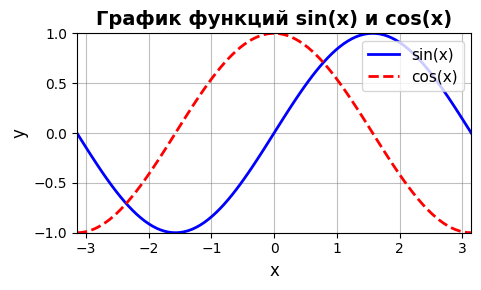

In [3]:
x = np.linspace(-np.pi, np.pi, 100)


y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure(figsize=(5, 3))

plt.plot(x, y_sin, color='blue', linestyle='-', linewidth=2, label='sin(x)')
plt.plot(x, y_cos, color='red', linestyle='--', linewidth=2, label='cos(x)')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)

plt.title('График функций sin(x) и cos(x)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')

plt.grid(True, linestyle='-', alpha=0.5, color='gray')

plt.xlim(-np.pi, np.pi)
plt.ylim(-1.0, 1.0)

plt.tight_layout()
plt.show()

In [4]:
# то что должно получиться

### Задание 2 (0.5 балла)

Прочитайте средствами pandas файл с данными кредитного скоринга. Рассмотрите сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

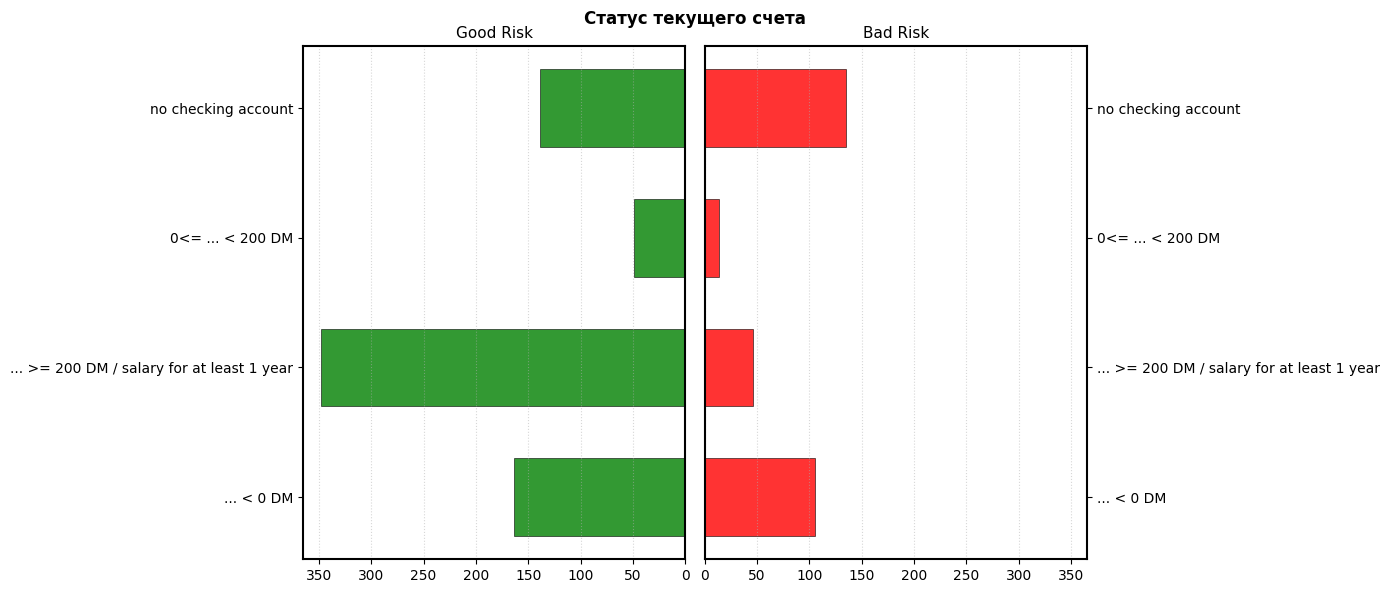

In [5]:
df = pd.read_csv(GERMAN_CREDIT)

grouped = df.groupby(['status', 'credit_risk']).size().unstack(fill_value=0)

categories = list(grouped.index)
good_counts = grouped['good'].values
bad_counts = grouped['bad'].values
max_count = max(good_counts.max(), bad_counts.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

fig.suptitle('Статус текущего счета', fontweight='bold')

y_pos = np.arange(len(categories))

ax1.barh(y_pos, good_counts, height=0.6, color='green', alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories)
ax1.set_title('Good Risk', fontsize=11)
ax1.invert_xaxis()
ax1.grid(True, axis='x', linestyle=':', alpha=0.5)
ax1.set_xlim(max_count * 1.05, 0)

for spine in ax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

ax2.barh(y_pos, bad_counts, height=0.6, color='red', alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(categories)
ax2.set_title('Bad Risk', fontsize=11)
ax2.grid(True, axis='x', linestyle=':', alpha=0.5)
ax2.set_xlim(0, max_count * 1.05)


for spine in ax2.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

ax2.tick_params(labelleft=False, labelright=True)
ax2.yaxis.tick_right()

plt.tight_layout()
plt.subplots_adjust(top=0.92, wspace=0.05)
plt.show()

In [6]:
# то что должно получиться

### Задание 3  (0.5 балла)

In [7]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

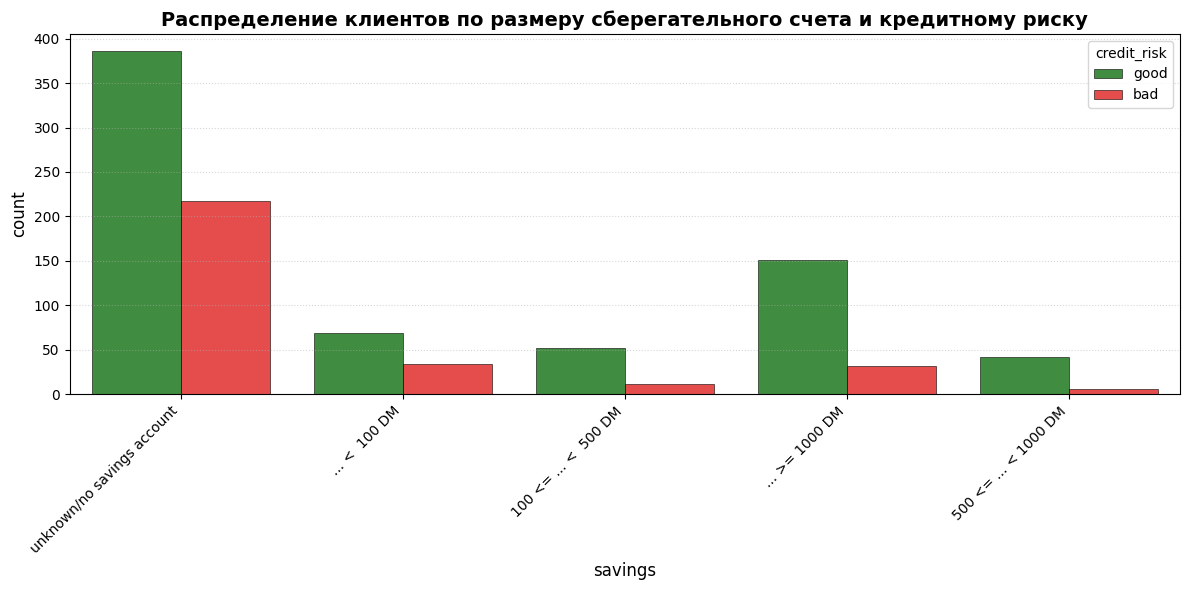

In [8]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='savings', hue='credit_risk',
              palette={'good': 'green', 'bad': 'red'},
              alpha=0.8, edgecolor='black', linewidth=0.5)

plt.xlabel('savings', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.title('Распределение клиентов по размеру сберегательного счета и кредитному риску', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='credit_risk', fontsize=10)
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
# то что должно получиться

### Задание 4  (0.5 балла)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

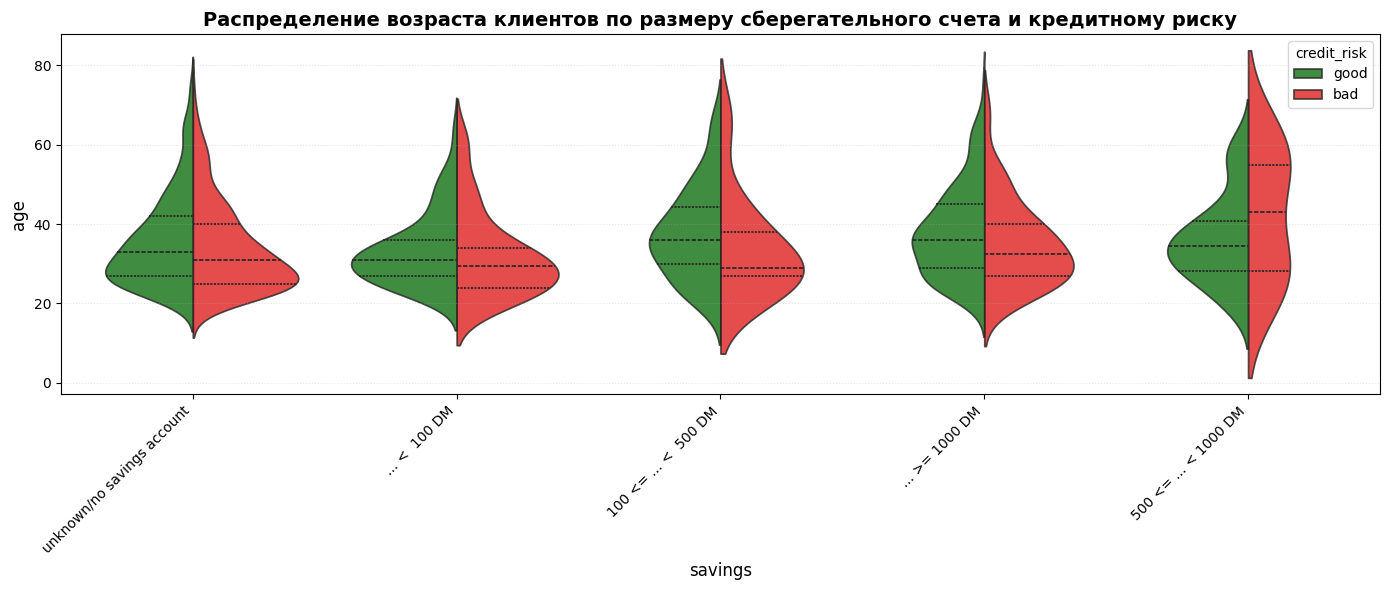

In [10]:
plt.figure(figsize=(14, 6))

sns.violinplot(data=df, x='savings', y='age', hue='credit_risk',
               palette={'good': 'green', 'bad': 'red'},
               split=True, inner='quartile', alpha=0.8)

plt.xlabel('savings', fontsize=12)
plt.ylabel('age', fontsize=12)
plt.title('Распределение возраста клиентов по размеру сберегательного счета и кредитному риску',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='credit_risk', fontsize=10)
plt.grid(True, axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# то что должно получиться

### Задание 5  (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

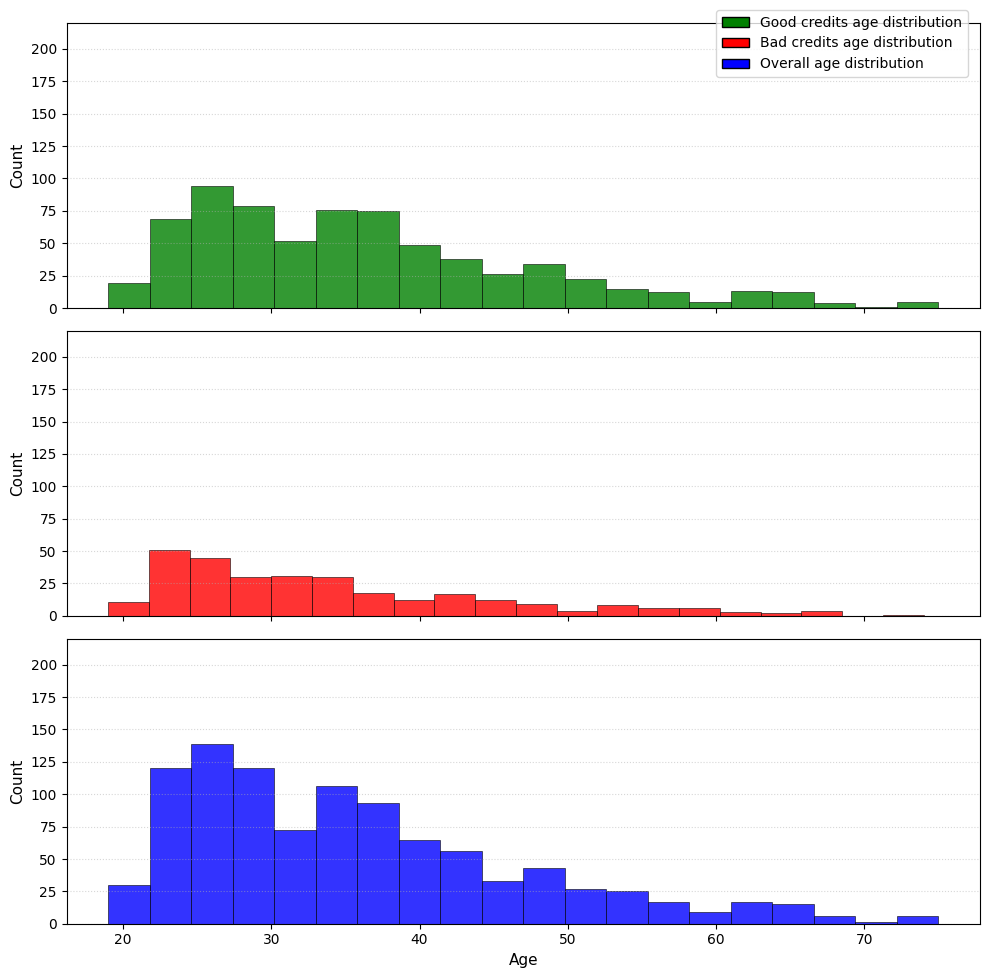

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

good_data = df[df['credit_risk'] == 'good']['age']
axes[0].hist(good_data, bins=20, color='green', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(True, axis='y', linestyle=':', alpha=0.5)
axes[0].set_ylim(0, 220)

bad_data = df[df['credit_risk'] == 'bad']['age']
axes[1].hist(bad_data, bins=20, color='red', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(True, axis='y', linestyle=':', alpha=0.5)
axes[1].set_ylim(0, 220)

axes[2].hist(df['age'], bins=20, color='blue', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_xlabel('Age', fontsize=11)
axes[2].grid(True, axis='y', linestyle=':', alpha=0.5)
axes[2].set_ylim(0, 220)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Good credits age distribution'),
    Patch(facecolor='red', edgecolor='black', label='Bad credits age distribution'),
    Patch(facecolor='blue', edgecolor='black', label='Overall age distribution')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.96)
plt.show()

In [13]:
# то что должно получиться

### Задание 6  (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

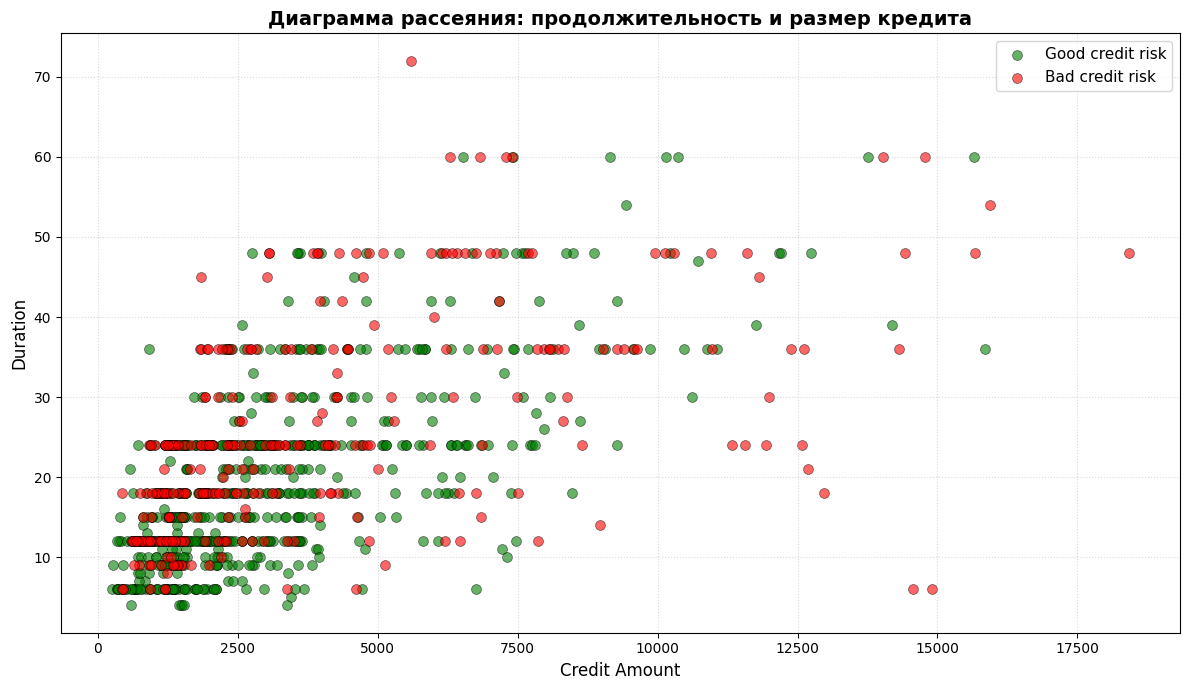

In [14]:
plt.figure(figsize=(12, 7))

good_credits = df[df['credit_risk'] == 'good']
bad_credits = df[df['credit_risk'] == 'bad']

plt.scatter(good_credits['amount'], good_credits['duration'], c='green', alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Good credit risk')
plt.scatter(bad_credits['amount'], bad_credits['duration'], c='red', alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Bad credit risk')

plt.ylabel('Duration', fontsize=12)
plt.xlabel('Credit Amount', fontsize=12)
plt.title('Диаграмма рассеяния: продолжительность и размер кредита', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [15]:
# то что должно получиться

### Задание 7  (0.5 балла)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

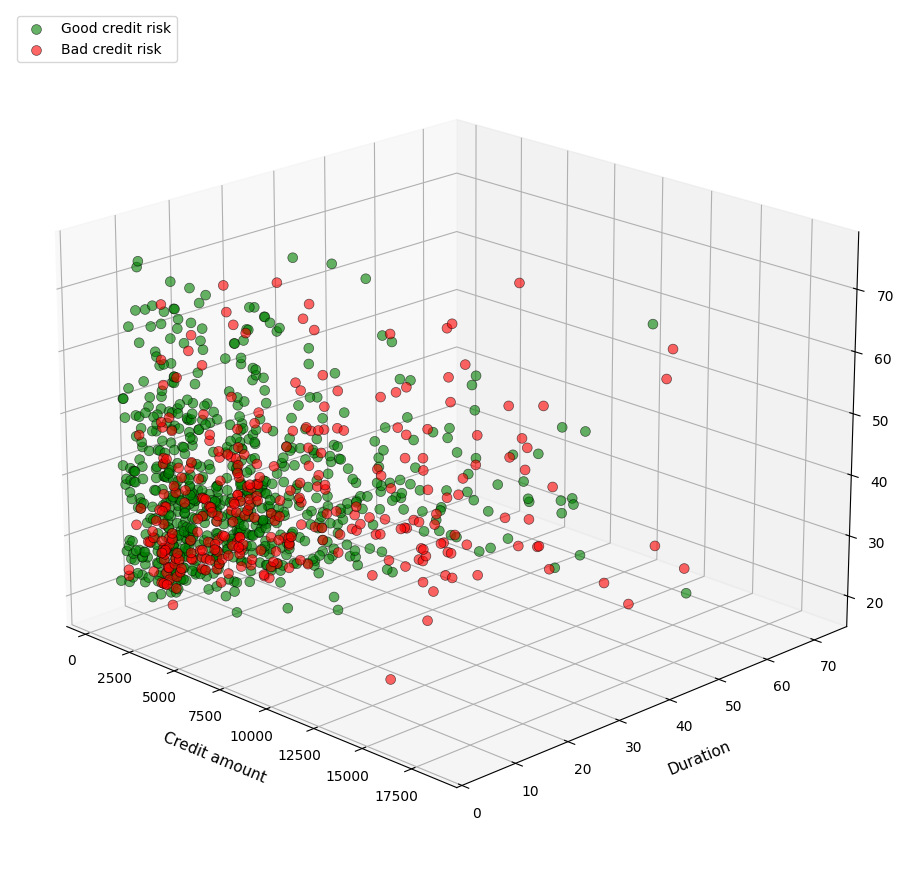

In [16]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(good_credits['amount'], good_credits['duration'], good_credits['age'], c='green', alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Good credit risk')
ax.scatter(bad_credits['amount'], bad_credits['duration'], bad_credits['age'], c='red', alpha=0.6, s=50, edgecolors='black', linewidth=0.5, label='Bad credit risk')

ax.set_xlabel('Credit amount', fontsize=11, labelpad=10)
ax.set_ylabel('Duration', fontsize=11, labelpad=10)
ax.set_zlabel('Age', fontsize=11, labelpad=10)

ax.legend(fontsize=10, loc='upper left')

ax.view_init(elev=20, azim=315)

ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


In [17]:
# то что должно получиться

Что вы можете сказать о сравнении 3D- и 2D-визуализаций? Какие вы видите в них преимущества и недостатки?

Какие выводы с точки зрения бизнеса можно сделать из полученного графика?

**ВАШ ОТВЕТ**  
Ну конечно 3D сильно информативней, в 2 раза по сути, у нас же график по 3 осям и можем смотреть на закономерность по каждой паре осей.
Но лично мне на двумерных графиках например распределения видно что-то, а тут во могом просто каша из точек.

Из того что точки сильно перемешаны и нет никаких "сгустков" цветов понятно, что только по возрасту, сумме и сроку невозможно сказать о надежности клиента

## Раздел 2. Визуализации в датасете Netflix

В данном разделе вы продолжите практиковаться в визуализациях и поработаете с более сложными графиками и инструментами.

Все технические рекомендации остаются неизменными с прошлого раздела.

In [18]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'

### Задание 1  (0.5 балла)

Прочитайте средствами pandas файл с данными Netflix. Посчитайте количество пропусков (NaN) в колонке `director`. Постройте столбчатую диаграмму, которая показывает 5 стран, в которых наибольшее количество фильмов содержат пропуски в столбце `director`.

Добавьте на диаграмму:

- Заголовок жирным шрифтом
- Подписи осей

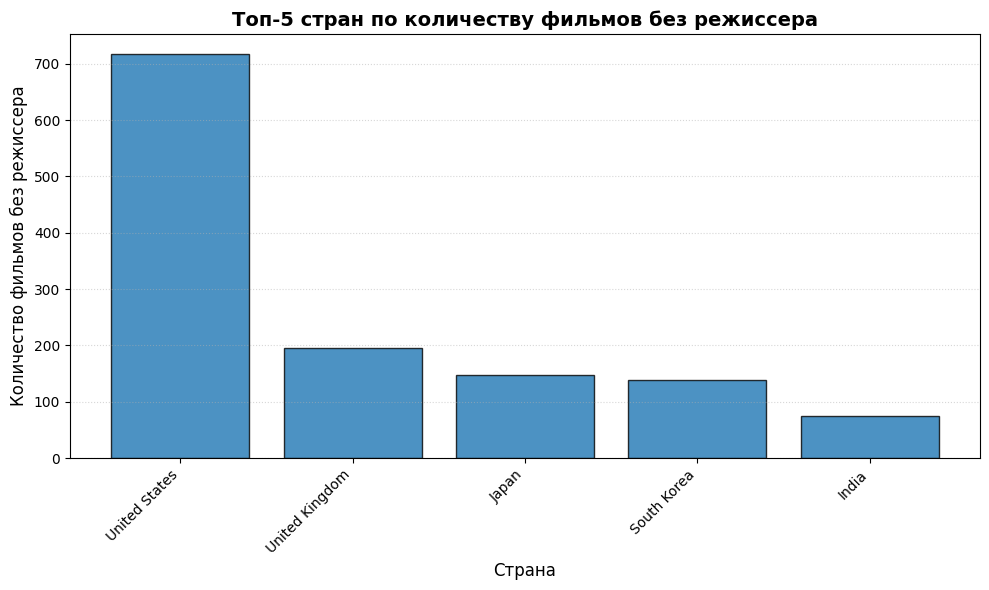

In [19]:
df = pd.read_csv(NETFLIX_TITLES)

df_no_director = df[df['director'].isna()]

country_counts = df_no_director['country'].value_counts().head(5)

plt.figure(figsize=(10, 6))

plt.bar(country_counts.index, country_counts.values, alpha=0.8, edgecolor='black', linewidth=1)

plt.xlabel('Страна', fontsize=12)
plt.ylabel('Количество фильмов без режиссера', fontsize=12)
plt.title('Топ-5 стран по количеству фильмов без режиссера', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Задание 2 (0.5 балла)

Постройте pie chart (круговую диаграмму), показывающую 5 стран, в которых произвели больше всего фильмов.

Добавьте на диаграмму:

+ Заголовок (Тип шрифта: ``family = 'monospace'``, насыщенность: ``fontweight='bold'``)
+ Название стран (Тип шрифта: ``family = 'monospace'``)
+ Подписи значений (%) (Тип шрифта: ``family = 'monospace'``)
+ Выберите стиль для диаграммы pastel c помощью библиотеки ``seaborn``

```colors = sns.color_palette('pastel')[0:5]```

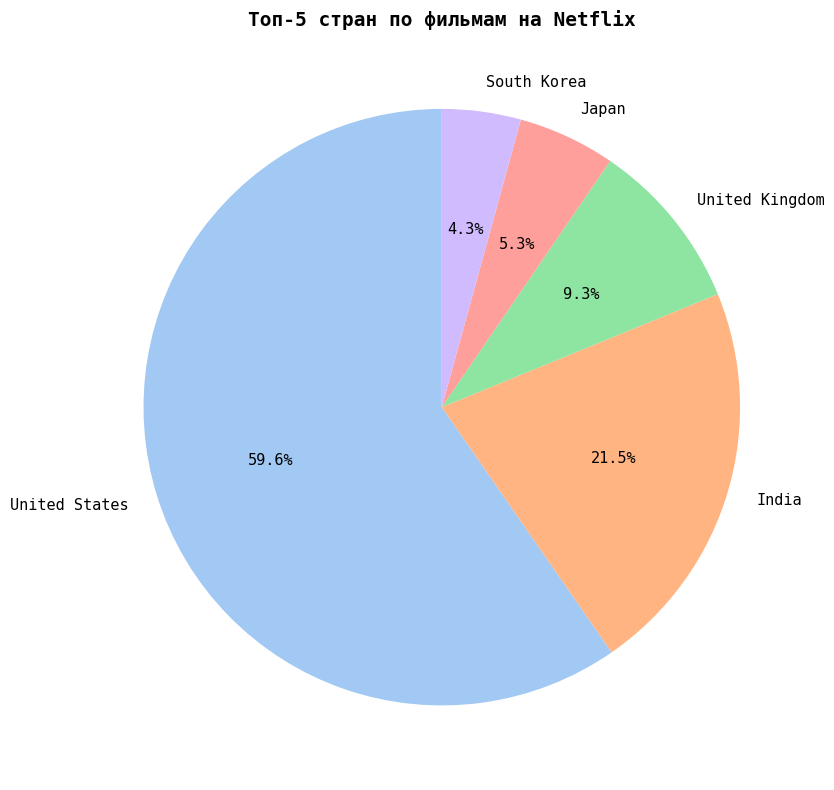

In [20]:
country_counts = df['country'].value_counts().head(5)

colors = sns.color_palette('pastel')[0:5]

plt.figure(figsize=(10, 8))

plt.pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%', colors=colors, startangle=90, textprops={'family': 'monospace', 'fontsize': 11})

plt.title('Топ-5 стран по фильмам на Netflix', fontsize=14, fontweight='bold', family='monospace')

plt.tight_layout()
plt.show()

### Задание 3 (1 балл)

Постройте subplots, где на первом графике будет круговая диаграмма, показывающая долю фильмов каждого рейтинга *(rating)*, а на втором столбчатая диаграмма, показывающая 3 страны, в которых было снято больше всего фильмов с рейтингом TV-MA.

*Если фильмов в каких-то рейтингах меньше 50, то их в график брать не нужно.*

Добавьте на диаграммы:

+ Заголовки (можно жирным)

Круговая диаграмма:
+ Подписи значений абсолютные

Столбчатая диаграммма:
+ Сделайте так, чтобы ось Y была справа
+ Добавьте подпись «Количество фильмов» к оси Y и уберите подпись к оси X
+ Оставьте видимыми только правую и нижнюю границы

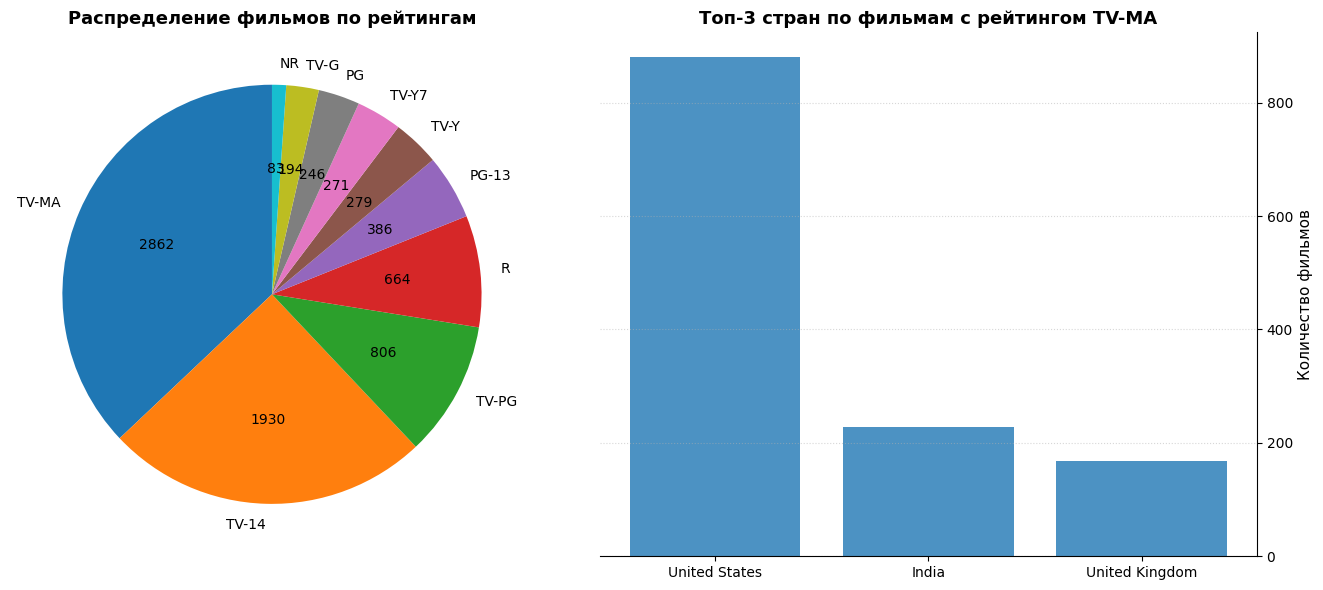

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

rating_counts = df['rating'].value_counts()
rating_filtered = rating_counts[rating_counts >= 50]

ax1.pie(rating_filtered.values, labels=rating_filtered.index, autopct=lambda pct: f'{int(pct/100 * rating_filtered.sum())}', startangle=90, textprops={'fontsize': 10})
ax1.set_title('Распределение фильмов по рейтингам', fontsize=13, fontweight='bold')

df_tvma = df[df['rating'] == 'TV-MA']
country_tvma = df_tvma['country'].value_counts().head(3)

ax2.bar(country_tvma.index, country_tvma.values,alpha=0.8, linewidth=1)

ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('Количество фильмов', fontsize=11)
ax2.set_xlabel('')

ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.set_title('Топ-3 стран по фильмам с рейтингом TV-MA', fontsize=13, fontweight='bold')
ax2.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### Задание 4 (1 балл)

Преобразуйте колонку `date_added` в datetime. Создайте новые столбцы month и year из преобразованного столбца. Постройте линейный график: сколько в среднем фильмов было снято в каждый из месяцев.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Маркеры на точках перегиба
+ Настройте ось X: ось начинается с 1 заканчивается 12, шаг 1

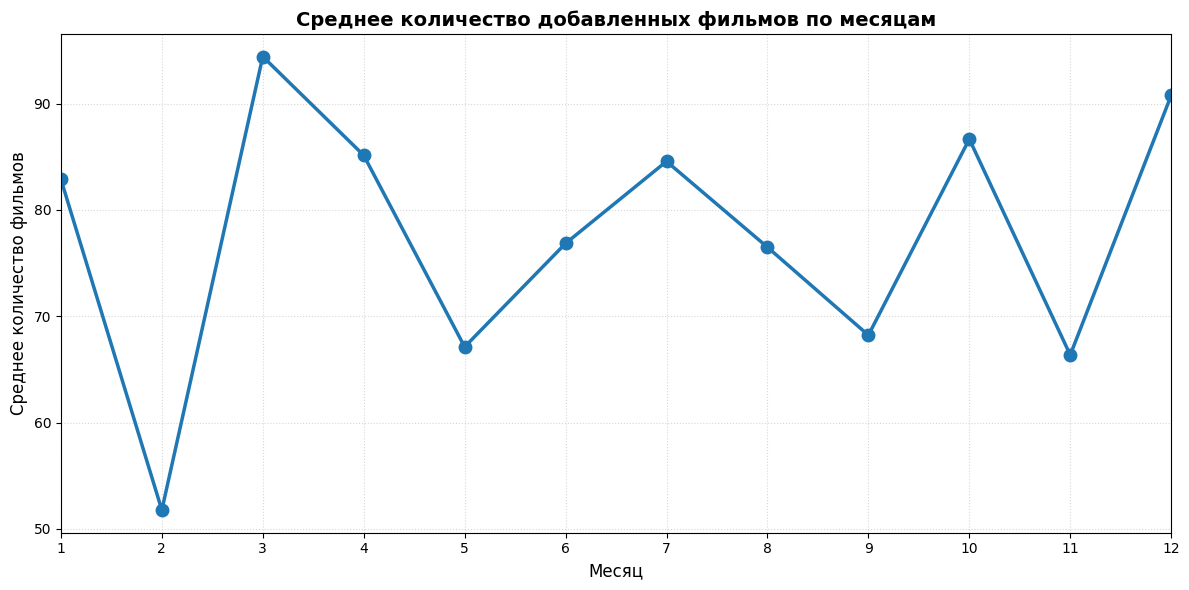

In [22]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['month'] = df['date_added'].dt.month
df['year'] = df['date_added'].dt.year

monthly_avg = df.groupby(['year', 'month']).size().groupby('month').mean()

plt.figure(figsize=(12, 6))

plt.plot(monthly_avg.index, monthly_avg.values, linewidth=2.5, marker='o', markersize=8, markeredgewidth=2)

plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Среднее количество фильмов', fontsize=12)
plt.title('Среднее количество добавленных фильмов по месяцам', fontsize=14, fontweight='bold')

plt.xticks(np.arange(1, 13, 1))
plt.xlim(1, 12)

plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Задание 5 (1 балл)

Постройте линейный график, в какие годы (столбец year, который вы создали в задании 4) сколько фильмов было снято.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Измените цвет линии графика и сделайте ее пунктиром
+ Решетку на фон

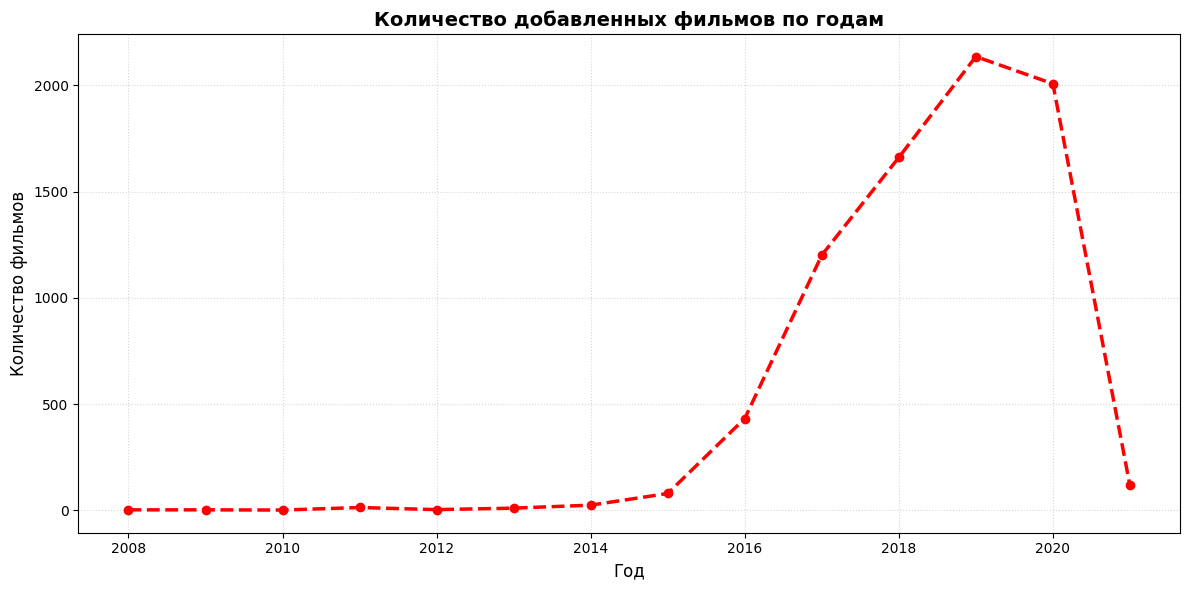

In [23]:
yearly_counts = df.groupby('year').size().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(yearly_counts.index, yearly_counts.values, color='red', linewidth=2.5, linestyle='--', marker='o', markersize=6)

plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество фильмов', fontsize=12)
plt.title('Количество добавленных фильмов по годам', fontsize=14, fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Задание 6 (1 балл)

Будем работать со столбцом duration. Одни данные даны в минутах (для фильмов (Movie)), а другие в сезонах (для сериалов (TV shows)). Создайте два новых столбца min (для тех, у кого продолжительность в минутах) и season (для тех, у кого продолжительность в сезонах), в которых будут извлечены данные из столбца duration.

Постройте subplots, где на первом графике гистрограмма распределения продолжительности фильмов, а на втором – гистрограмма распределения продолжительности сериалов.

Добавьте на графики:

+ Заголовки жирным шрифтом
+ Подписи осей

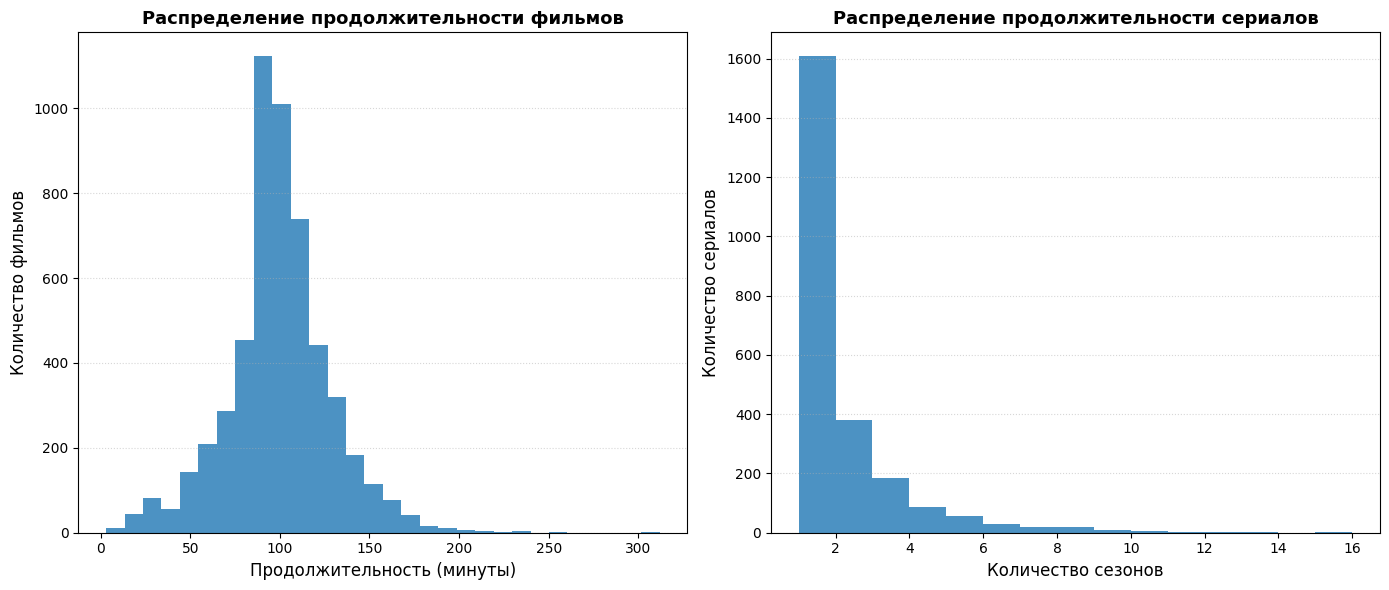

In [24]:
df['min'] = df[df['type'] == 'Movie']['duration'].str.extract('(\d+)').astype(float)

df['season'] = df[df['type'] == 'TV Show']['duration'].str.extract('(\d+)').astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(df['min'].dropna(), bins=30, alpha=0.8, linewidth=0.5)
ax1.set_xlabel('Продолжительность (минуты)', fontsize=12)
ax1.set_ylabel('Количество фильмов', fontsize=12)
ax1.set_title('Распределение продолжительности фильмов', fontsize=13, fontweight='bold')
ax1.grid(True, axis='y', linestyle=':', alpha=0.5)

ax2.hist(df['season'].dropna(), bins=15, alpha=0.8, linewidth=0.5)
ax2.set_xlabel('Количество сезонов', fontsize=12)
ax2.set_ylabel('Количество сериалов', fontsize=12)
ax2.set_title('Распределение продолжительности сериалов', fontsize=13, fontweight='bold')
ax2.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Задание 7 (0.5 балла)

Постройте ящик с усами (box plot) по продолжительности фильмов (Movies). Визуально проинтерпретируйте его.

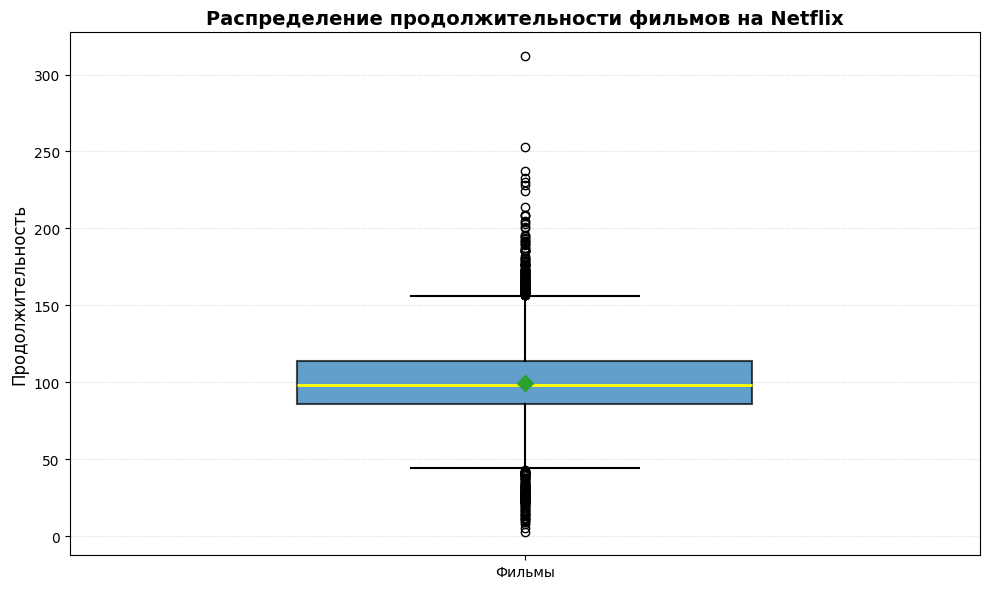

In [25]:
plt.figure(figsize=(10, 6))

box = plt.boxplot(df['min'].dropna(), patch_artist=True,
                  widths=0.5,
                  showmeans=True,
                  boxprops=dict(alpha=0.7, linewidth=1.5),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5),
                  medianprops=dict(color='yellow', linewidth=2),
                  meanprops=dict(marker='D', markersize=8))

plt.ylabel('Продолжительность', fontsize=12)
plt.title('Распределение продолжительности фильмов на Netflix', fontsize=14, fontweight='bold')
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.xticks([1], ['Фильмы'])

plt.tight_layout()
plt.show()

### Задание 8* (1 балл)

Постройте при помощи библиотеки plotly интерактивную столбчатую диаграмму, которая сравнивает среднюю продолжительность фильмов и сериалов за каждый год, начиная с 2000.

In [28]:
import plotly.graph_objects as go

df_filtered = df[df['year'] >= 2000]

movies_avg = df_filtered[df_filtered['type'] == 'Movie'].groupby('year')['min'].mean()
tvshows_avg = df_filtered[df_filtered['type'] == 'TV Show'].groupby('year')['season'].mean()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=movies_avg.index,
    y=movies_avg.values,
    name='Фильмы (минуты)',
    hovertemplate='<b>Год:</b> %{x}<br><b>Средняя продолжительность:</b> %{y:.1f} мин<extra></extra>'
))

fig.add_trace(go.Bar(
    x=tvshows_avg.index,
    y=tvshows_avg.values,
    name='Сериалы (сезоны)',
    hovertemplate='<b>Год:</b> %{x}<br><b>Среднее количество сезонов:</b> %{y:.1f}<extra></extra>'
))

fig.update_layout(
    title='<b>Средняя продолжительность фильмов и сериалов по годам (с 2000)</b>',
    xaxis_title='Год',
    yaxis_title='Средняя продолжительность',
    barmode='group',
    hovermode='x unified',
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    height=600
)

fig.show()
